Goal: helping the company identify high-value customer segments, prioritize marketing efforts, and develop more effective customer retention strategies.

Approach: using publicly available e-commerce transaction data and supervised machine learning techniques to build a model that predicts which customers are most likely to become repeat purchasers.

Successful outcome: build a model that predicts repeat customers and provides actionable marketing recommendations

In [2]:
import os
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_excel('https://raw.githubusercontent.com/Break-Through-Tech/witOmni-1A-ai-powered-customer-intelligence-for-smarter-marketing/main/data/Online%20Retail.xlsx', header=0)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Data type: Numerical and nominal

Format: CSV / Structured tabular data

Feature Type: Integer, Real

Instances: 541909

Features: 6

Data set size: 22.6 MB


Ethical Concerns: 

The Country section on the UCI Online Retail dataset may lead to discrimination toward certain nationalities or ethnic groups. 

Those with lower income may not be classified as “high-value customers” and focusing marketing efforts away from them could push them farther away from becoming repeat buyers


# Business Understanding

# Data Cleaning

May have to one-hot encode categorical data

Clean up any missing data 

Can exclude invoice number, and get rid of data associated with cancelled invoice number (starting with ‘c’)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# Data Exploration

# Data Cleaning

# Data Visualization


In [7]:
df.corr(method='pearson', numeric_only = True)

,Quantity,UnitPrice,CustomerID
Quantity,1.000000,-0.001235,-0.00360
UnitPrice,-0.001235,1.000000,-0.00456
CustomerID,-0.003600,-0.004560,1.00000


<Axes: title={'center': 'Distribution of Total Price'}, ylabel='Frequency'>

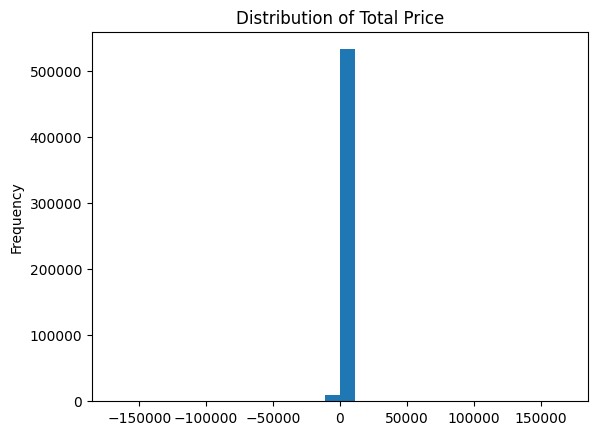

In [8]:
df["TotalPrice"] = df['Quantity'] * df['UnitPrice']
df['TotalPrice'].plot(kind='hist', bins=30, title = "Distribution of Total Price")

<Axes: title={'center': 'Box Plot of Total Price'}>

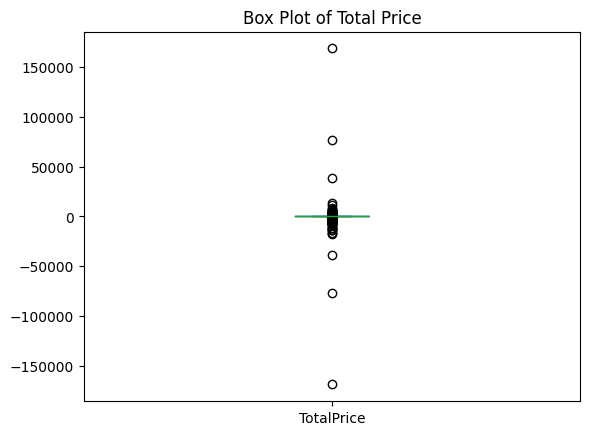

In [9]:
df['TotalPrice'].plot(kind='box', title='Box Plot of Total Price')


<Axes: ylabel='Frequency'>

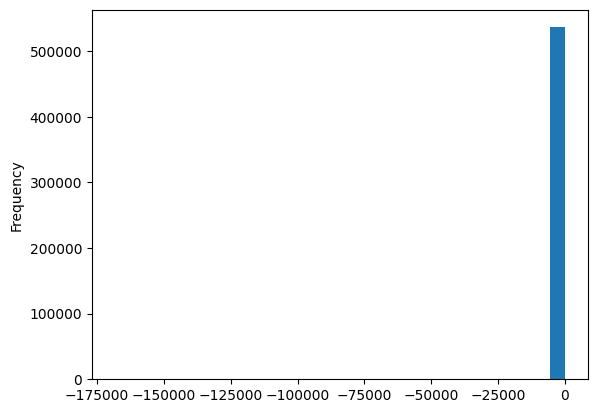

In [10]:
q_high = df['TotalPrice'].quantile(0.99)
df[df['TotalPrice'] < q_high]['TotalPrice'].plot(kind='hist', bins=30)

<Axes: >

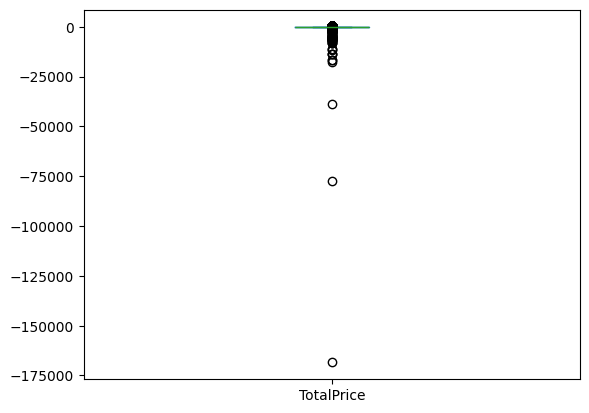

In [11]:
df[df['TotalPrice'] < q_high]['TotalPrice'].plot(kind='box')

<Axes: title={'center': 'Distribution of Quantity'}, ylabel='Frequency'>

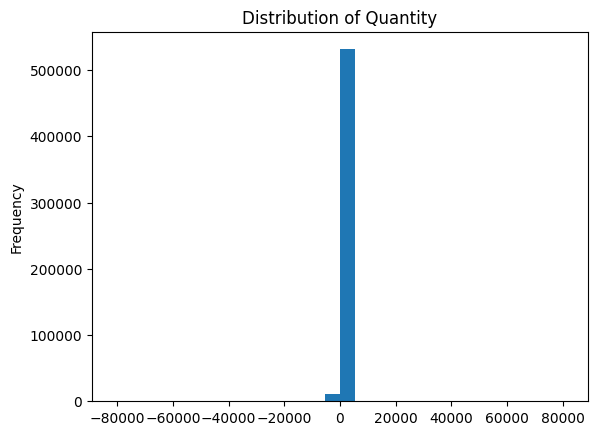

In [12]:
df['Quantity'].plot(kind='hist', bins=30, title = "Distribution of Quantity")

<Axes: title={'center': 'Box Plot of Quantity'}>

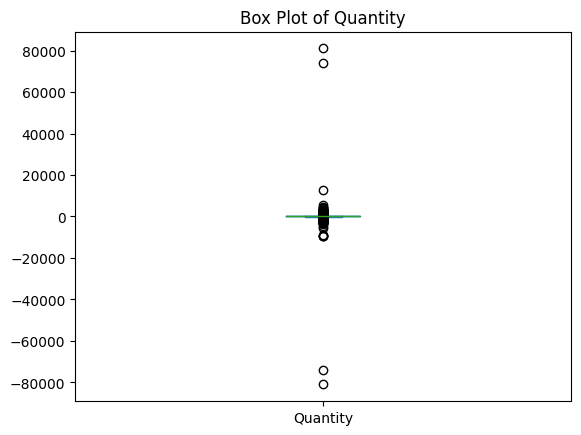

In [13]:
df['Quantity'].plot(kind='box', title='Box Plot of Quantity')


<Axes: title={'center': 'Distribution of Unit Price'}, ylabel='Frequency'>

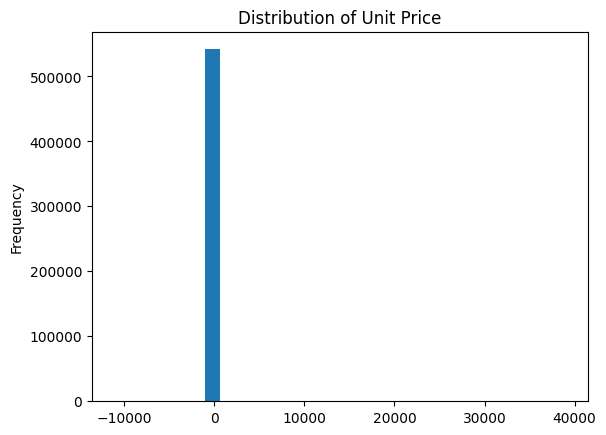

In [14]:
df['UnitPrice'].plot(kind='hist', bins=30, title = "Distribution of Unit Price")

<Axes: title={'center': 'Box Plot of Unit Price'}>

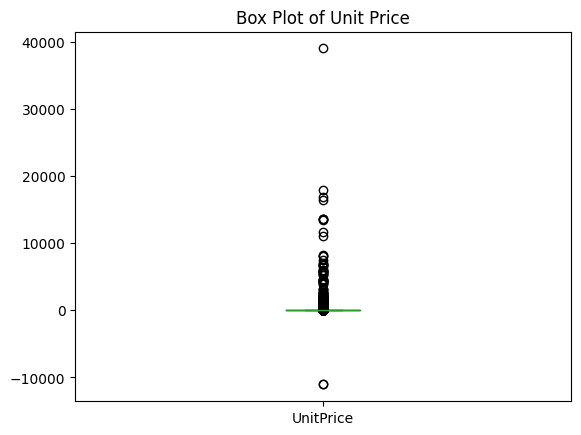

In [15]:
df['UnitPrice'].plot(kind='box', title='Box Plot of Unit Price')


# Customer Feature Engineering